In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

In [3]:
data_path = Path("data/")

In [4]:
image_path = data_path / "desert101"

In [5]:
image_path

WindowsPath('data/desert101')

In [6]:
import os

In [7]:
def check_data(dir_path):
    for dirpath, dirnames, filename in os.walk(dir_path):
        print(f"# of directories: {len(dirnames)} and {len(filename)} images in {dirpath}")

In [8]:
check_data(image_path)

# of directories: 2 and 1 images in data\desert101
# of directories: 4 and 1 images in data\desert101\test
# of directories: 0 and 20 images in data\desert101\test\baklava
# of directories: 0 and 20 images in data\desert101\test\cannoli
# of directories: 0 and 20 images in data\desert101\test\cup_cakes
# of directories: 0 and 20 images in data\desert101\test\donuts
# of directories: 4 and 1 images in data\desert101\train
# of directories: 0 and 80 images in data\desert101\train\baklava
# of directories: 0 and 80 images in data\desert101\train\cannoli
# of directories: 0 and 80 images in data\desert101\train\cup_cakes
# of directories: 0 and 80 images in data\desert101\train\donuts


In [9]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [10]:
train_dir

WindowsPath('data/desert101/train')

In [11]:
test_dir

WindowsPath('data/desert101/test')

In [12]:
from PIL import Image
import random

In [13]:
random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image = random.choice(image_path_list)
img = Image.open(random_image)

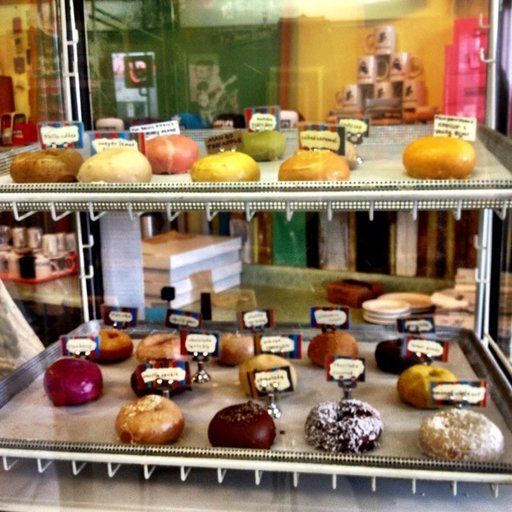

In [14]:
img

In [15]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [16]:
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,saturation=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std = [0.229,0.224,0.225])
])

In [17]:
test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std = [0.229,0.224,0.225])
])

In [18]:
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

test_data = datasets.ImageFolder(
    root = test_dir,
    transform=test_transform
)

In [19]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: data\desert101\train
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
               ToTensor()
               RandomErasing(p=0.2, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [20]:
test_data

Dataset ImageFolder
    Number of datapoints: 77
    Root location: data\desert101\test
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [21]:
class_names = train_data.classes

In [22]:
class_names

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [23]:
len(train_data), len(test_data)

(316, 77)

In [24]:
BATCH_SIZE = 32
NUM_WORKERS = 4

In [25]:
import torch

print(torch.cuda.is_available())

True


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [27]:
train_dataloader = DataLoader(
    dataset = train_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    pin_memory=True,
    persistent_workers=True
)

test_dataloader = DataLoader(
    dataset = test_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    pin_memory=True,
    persistent_workers=True
)

In [28]:
train_dataloader.dataset[0][0]

tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],

        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.8044,  ..., -1

In [29]:
class DesertClassifier(nn.Module):
    def __init__(self,input_shape:int, hidden_units: int, output_shape:int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input_shape,
                      hidden_units,
            kernel_size=3,
            padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
    
            nn.Conv2d(hidden_units,
            hidden_units,
            kernel_size=3,
            padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
            stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units,
            hidden_units*2,
            kernel_size=3,
            padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
    
            nn.Conv2d(hidden_units*2,
            hidden_units*2,
            kernel_size=3,
            padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(hidden_units*2,
            hidden_units*4,
            kernel_size=3,
            padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
    
            nn.Conv2d(hidden_units*4,
            hidden_units*4,
            kernel_size=3,
            padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(hidden_units*4,output_shape)
        )
    def forward(self,x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.classifier(x)

        return x

In [30]:
x = torch.randn(1,3,64,64)

print("Input: ",x.shape)

conv1 = nn.Conv2d(in_channels=3,
                    out_channels = 10,
                    kernel_size=3,
                    stride = 1,
                    padding=1)
conv2 = nn.Conv2d(in_channels=10,
                    out_channels = 10,
                    kernel_size=3,
                    stride = 1,
                    padding=1)
pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

x = conv1(x)
print("After Conv1: ", x.shape)

x = conv2(x)
print("After Conv2: ",x.shape)

x = pool1(x)
print("After Pool1 : ",x.shape)

conv3 = nn.Conv2d(in_channels=10,
                    out_channels = 10,
                    kernel_size=3,
                    stride = 1,
                    padding=1)
conv4 = nn.Conv2d(in_channels=10,
                    out_channels = 10,
                    kernel_size=3,
                    stride = 1,
                    padding=1)
pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

x = conv3(x)
print("After Conv3: ", x.shape)

x = conv4(x)
print("After Conv4: ",x.shape)

x = pool2(x)
print("After Pool2 : ",x.shape)

Input:  torch.Size([1, 3, 64, 64])
After Conv1:  torch.Size([1, 10, 64, 64])
After Conv2:  torch.Size([1, 10, 64, 64])
After Pool1 :  torch.Size([1, 10, 32, 32])
After Conv3:  torch.Size([1, 10, 32, 32])
After Conv4:  torch.Size([1, 10, 32, 32])
After Pool2 :  torch.Size([1, 10, 16, 16])


In [31]:
import torchvision.models as models

In [32]:
model = DesertClassifier(input_shape=3,
                            hidden_units=32,
                           output_shape=len(class_names)).to(device)

In [33]:
len(class_names)

4

In [34]:
from torchinfo import summary

In [35]:
summary(model,input_size=[1,3,128,128],device=str(device))

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 64, 64]           --
│    └─Conv2d: 2-1                       [1, 32, 128, 128]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 128, 128]         64
│    └─ReLU: 2-3                         [1, 32, 128, 128]         --
│    └─Conv2d: 2-4                       [1, 32, 128, 128]         9,248
│    └─BatchNorm2d: 2-5                  [1, 32, 128, 128]         64
│    └─ReLU: 2-6                         [1, 32, 128, 128]         --
│    └─MaxPool2d: 2-7                    [1, 32, 64, 64]           --
├─Sequential: 1-2                        [1, 64, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 64, 64, 64]           18,496
│    └─BatchNorm2d: 2-9                  [1, 64, 64, 64]           128
│    └─ReLU: 2-10                        [1, 64, 64, 64]           --
│    └

In [36]:
128*16*16

32768

In [37]:
!pip install tqdm

In [38]:
from tqdm.auto import tqdm

C:\Users\rarsl\anaconda3\envs\deeplearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
from torchvision.transforms import v2

In [40]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer,scheduler=None,
              cutmix_or_mixup=None):

    model.train()

    train_loss = 0
    train_acc = 0

    for batch, (X,y) in enumerate(tqdm(dataloader)):
        X = X.to(device)
        y = y.to(device)

        if cutmix_or_mixup is not None:
               
            X, y = cutmix_or_mixup(X,y)
        
        y_pred = model(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        y_pred_class = torch.argmax(y_pred, dim = 1)
        correct = (y_pred_class == y.argmax(dim=1)).sum().item()
        train_acc += correct / y.size(0)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [41]:
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

    model.eval()

    test_loss=0
    test_acc=0

    with torch.inference_mode():
        for batch, (X,y) in enumerate(tqdm(dataloader)):
            X = X.to(device)
            y = y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [42]:
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          scheduler = None,
          loss_fn: torch.nn.Module=nn.CrossEntropyLoss(),
          epochs :int=10,
         cutmix_or_mixup=None):
    results = {"train_loss" : [],
               "train_acc": [],
               "test_loss" : [],
               "test_acc" : []
              }
    best_test_loss = float("inf")
    
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn = loss_fn,
                                           optimizer=optimizer,
                                          scheduler=scheduler,
                                          cutmix_or_mixup=cutmix_or_mixup)
        test_loss, test_acc = test_step(model=model,
        dataloader=test_dataloader,
        loss_fn = loss_fn)

        current_lr = optimizer.param_groups[0]["lr"]

        print(f"Epoch: [{epoch+1}/{epochs}] | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} - Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            torch.save(model.state_dict(),"best_model.pth")
            print(f"En iyi model -> Test Loss: {test_loss:.4f}")
            
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
    return results

In [43]:
EPOCHS = 100
model = DesertClassifier(input_shape=3,
                           hidden_units=64,
                           output_shape=len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss(label_smoothing = 0.1) # modelin tahminlerine aşırı güvenmesini(overconfident olmasını) engeller, test loss'u stabilize eder
optimizer = torch.optim.AdamW(params=model.parameters(),lr=1e-3,weight_decay=5e-4)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_dataloader),
    epochs=EPOCHS
)

mixup = v2.MixUp(num_classes=len(class_names))
cutmix = v2.CutMix(num_classes=len(class_names))
cutmix_or_mixup = v2.RandomChoice([mixup,cutmix])

model_results = train(model=model,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        loss_fn=loss_fn,
                        optimizer = optimizer,
                        scheduler = scheduler,
                        epochs=EPOCHS,
                     cutmix_or_mixup=cutmix_or_mixup)

model.load_state_dict(torch.load("best_model.pth"))
model.eval()
print("En iyi model yüklendi")

100%|██████████| 3/3 [00:05<00:00,  1.98s/it]


Epoch: [1/100] | LR: 0.000043 | Train Loss: 1.4360 | Train Acc: 0.2643 - Test Loss: 1.4081 | Test Acc: 0.1979
En iyi model -> Test Loss: 1.4081


100%|██████████| 3/3 [00:00<00:00,  7.18it/s]


Epoch: [2/100] | LR: 0.000051 | Train Loss: 1.3739 | Train Acc: 0.3799 - Test Loss: 1.4483 | Test Acc: 0.1979


100%|██████████| 3/3 [00:00<00:00,  7.93it/s]


...

Epoch: [98/100] | LR: 0.000002 | Train Loss: 1.0677 | Train Acc: 0.7170 - Test Loss: 1.1458 | Test Acc: 0.5393


100%|██████████| 3/3 [00:00<00:00,  7.49it/s]


Epoch: [99/100] | LR: 0.000000 | Train Loss: 1.0455 | Train Acc: 0.7232 - Test Loss: 1.1516 | Test Acc: 0.5753


100%|██████████| 3/3 [00:00<00:00,  7.18it/s]

Epoch: [100/100] | LR: 0.000000 | Train Loss: 1.0210 | Train Acc: 0.6960 - Test Loss: 1.1485 | Test Acc: 0.5857
En iyi model yüklendi


In [44]:
model_results

{'train_loss': [1.4359865069389344,
  1.3739345908164977,
  1.3599967002868651,
  1.3465526342391967,
  1.2828350901603698,
  1.3127317905426026,
  1.2857874989509583,
  1.3041083931922912,
  1.2820841550827027,
  1.2771055102348328,
  1.27570241689682,
  1.3505462646484374,
  1.3039960741996766,
  1.2898702025413513,
  1.3180562376976013,
  1.2661837577819823,
  1.2473137259483338,
  1.3121686816215514,
  1.2706905484199524,
  1.2740797638893127,
  1.2985620021820068,
  1.2621260166168213,
  1.288103199005127,
  1.2753124117851258,
  1.3103280901908874,
  1.2293321371078492,
  1.2773521780967712,
  1.306251323223114,
  1.261179780960083,
  1.2469264149665833,
  1.2633171796798706,
  1.2600953459739686,
  1.2691373109817505,
  1.2632678627967835,
  1.2526148319244386,
  1.224627685546875,
  1.229671835899353,
  1.2701027989387512,
  1.2266877055168153,
  1.2443816304206847,
  1.1963688135147095,
  1.2572681307792664,
  1.2730304718017578,
  1.1936910986900329,
  1.166817843914032,
  1.

In [45]:
def plot_loss_curves(results):
    loss = results["train_loss"]
    test_loss = results["test_loss"]
    train_accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(17,8))

    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, train_accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("accuracy")
    plt.xlabel("Epochs")
    plt.legend()

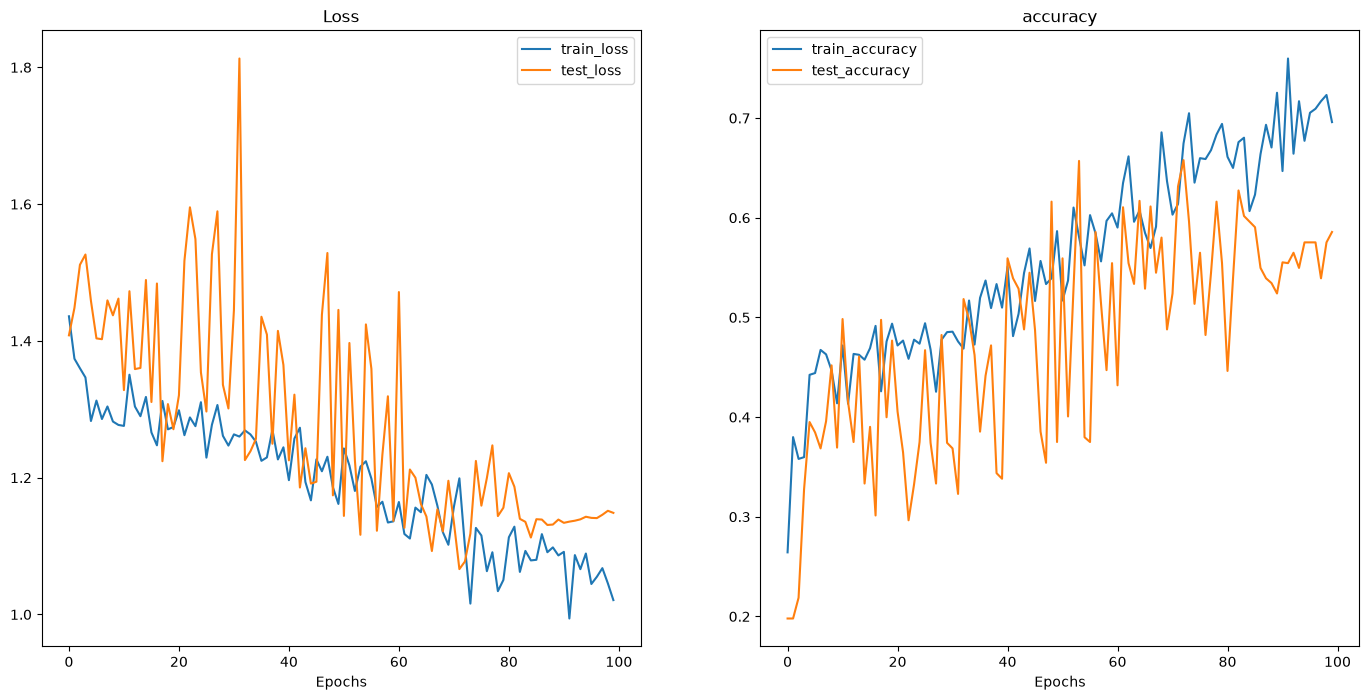

In [46]:
plot_loss_curves(model_results)

In [47]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [48]:
def predict_with_tta(model, image_tensor, class_names, n=8, image_size=128):
    model.eval()

    tta_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.Normalize(mean=[0.485,0.456,0.406],
                            std = [0.229,0.224,0.225])
    ])

    probs_sum=torch.zeros(1,len(class_names)).to(device)

    with torch.inference_mode():
        for _ in range(n):
            X = tta_transform(image_tensor).unsqueeze(0).to(device)
            probs_sum += torch.softmax(model(X), dim=1)

        probs_avg = probs_sum / n
        pred_idx = probs_avg.argmax(dim=1).item()

        print(f"Tahmin edilen tatlı: {class_names[pred_idx]}")
        print(f"Güven oranı: %{probs_avg[0][pred_idx].item()*100:.2f}")

        return probs_avg

In [49]:
import random
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()
    
    plt.figure(figsize=(4, 4))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0).to(device)
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute
            img_show = img.permute(1, 2, 0)

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.2535014].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.1345534].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..1.9951199].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.68244..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7906162..1.7511113].

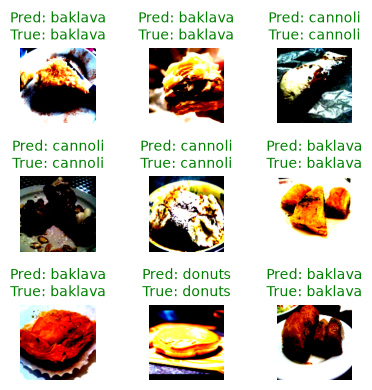

In [50]:
show_random_predictions(model,test_data,class_names)

In [67]:
online_image_path = data_path / "donut.jpg"

In [68]:
online_image_path

WindowsPath('data/donut.jpg')

In [69]:
import torchvision

In [70]:
single_image = torchvision.io.read_image(str(online_image_path))

In [71]:
single_image

tensor([[[128, 128, 128,  ..., 215, 215, 215],
         [126, 126, 126,  ..., 215, 215, 215],
         [123, 123, 123,  ..., 215, 215, 215],
         ...,
         [211, 211, 211,  ..., 241, 244, 244],
         [211, 211, 211,  ..., 244, 243, 243],
         [211, 211, 211,  ..., 244, 243, 243]],

        [[114, 114, 114,  ..., 215, 215, 215],
         [112, 112, 112,  ..., 215, 215, 215],
         [109, 109, 109,  ..., 215, 215, 215],
         ...,
         [205, 205, 205,  ..., 241, 244, 244],
         [205, 205, 205,  ..., 244, 243, 243],
         [205, 205, 205,  ..., 244, 243, 243]],

        [[105, 105, 105,  ..., 215, 215, 215],
         [103, 103, 103,  ..., 215, 215, 215],
         [100, 100, 100,  ..., 215, 215, 215],
         ...,
         [207, 207, 207,  ..., 241, 244, 244],
         [207, 207, 207,  ..., 244, 243, 243],
         [207, 207, 207,  ..., 244, 243, 243]]], dtype=torch.uint8)

In [72]:
single_image = torchvision.io.read_image(str(online_image_path)).type(torch.float32)

In [73]:
single_image

tensor([[[128., 128., 128.,  ..., 215., 215., 215.],
         [126., 126., 126.,  ..., 215., 215., 215.],
         [123., 123., 123.,  ..., 215., 215., 215.],
         ...,
         [211., 211., 211.,  ..., 241., 244., 244.],
         [211., 211., 211.,  ..., 244., 243., 243.],
         [211., 211., 211.,  ..., 244., 243., 243.]],

        [[114., 114., 114.,  ..., 215., 215., 215.],
         [112., 112., 112.,  ..., 215., 215., 215.],
         [109., 109., 109.,  ..., 215., 215., 215.],
         ...,
         [205., 205., 205.,  ..., 241., 244., 244.],
         [205., 205., 205.,  ..., 244., 243., 243.],
         [205., 205., 205.,  ..., 244., 243., 243.]],

        [[105., 105., 105.,  ..., 215., 215., 215.],
         [103., 103., 103.,  ..., 215., 215., 215.],
         [100., 100., 100.,  ..., 215., 215., 215.],
         ...,
         [207., 207., 207.,  ..., 241., 244., 244.],
         [207., 207., 207.,  ..., 244., 243., 243.],
         [207., 207., 207.,  ..., 244., 243., 243.]]]

In [74]:
single_image = single_image / 255

In [75]:
single_image

tensor([[[0.5020, 0.5020, 0.5020,  ..., 0.8431, 0.8431, 0.8431],
         [0.4941, 0.4941, 0.4941,  ..., 0.8431, 0.8431, 0.8431],
         [0.4824, 0.4824, 0.4824,  ..., 0.8431, 0.8431, 0.8431],
         ...,
         [0.8275, 0.8275, 0.8275,  ..., 0.9451, 0.9569, 0.9569],
         [0.8275, 0.8275, 0.8275,  ..., 0.9569, 0.9529, 0.9529],
         [0.8275, 0.8275, 0.8275,  ..., 0.9569, 0.9529, 0.9529]],

        [[0.4471, 0.4471, 0.4471,  ..., 0.8431, 0.8431, 0.8431],
         [0.4392, 0.4392, 0.4392,  ..., 0.8431, 0.8431, 0.8431],
         [0.4275, 0.4275, 0.4275,  ..., 0.8431, 0.8431, 0.8431],
         ...,
         [0.8039, 0.8039, 0.8039,  ..., 0.9451, 0.9569, 0.9569],
         [0.8039, 0.8039, 0.8039,  ..., 0.9569, 0.9529, 0.9529],
         [0.8039, 0.8039, 0.8039,  ..., 0.9569, 0.9529, 0.9529]],

        [[0.4118, 0.4118, 0.4118,  ..., 0.8431, 0.8431, 0.8431],
         [0.4039, 0.4039, 0.4039,  ..., 0.8431, 0.8431, 0.8431],
         [0.3922, 0.3922, 0.3922,  ..., 0.8431, 0.8431, 0.

Text(0.5, 1.0, 'torch.Size([3, 554, 554])')

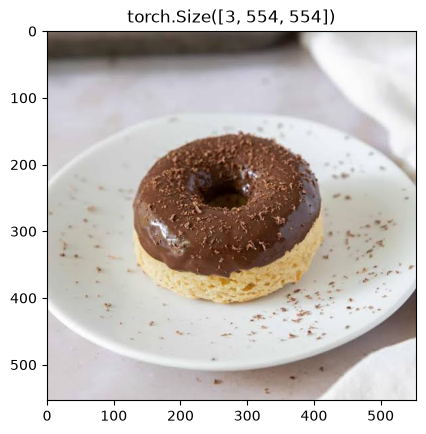

In [76]:
plt.imshow(single_image.permute(1,2,0))
plt.title(single_image.shape)

In [77]:
single_image.shape

torch.Size([3, 554, 554])

In [78]:
single_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 554, 554])

In [79]:
single_image = single_image.to(device)

In [80]:
probs = predict_with_tta(model, single_image,class_names, n=8)

Tahmin edilen tatlı: baklava
Güven oranı: %52.97


In [81]:
online_image2_path = data_path / "baklava.jpg"

In [82]:
online_image2_path

WindowsPath('data/baklava.jpg')

In [83]:
single_image2 = torchvision.io.read_image(str(online_image2_path))

In [84]:
single_image2 = torchvision.io.read_image(str(online_image2_path)).type(torch.float32)

In [85]:
single_image2 = single_image2 / 255

In [86]:
single_image2

tensor([[[0.8549, 0.8471, 0.8588,  ..., 0.8549, 0.8627, 0.8627],
         [0.8431, 0.8471, 0.8510,  ..., 0.8510, 0.8431, 0.8510],
         [0.8549, 0.8549, 0.8549,  ..., 0.8510, 0.8471, 0.8431],
         ...,
         [0.8745, 0.8824, 0.8745,  ..., 0.8431, 0.8549, 0.8431],
         [0.8902, 0.8863, 0.8863,  ..., 0.8863, 0.9020, 0.8667],
         [0.8627, 0.8706, 0.8706,  ..., 0.8863, 0.8902, 0.8588]],

        [[0.8353, 0.8275, 0.8392,  ..., 0.8353, 0.8431, 0.8431],
         [0.8235, 0.8275, 0.8314,  ..., 0.8314, 0.8235, 0.8314],
         [0.8353, 0.8353, 0.8353,  ..., 0.8314, 0.8275, 0.8235],
         ...,
         [0.8588, 0.8667, 0.8588,  ..., 0.8353, 0.8392, 0.8275],
         [0.8745, 0.8706, 0.8706,  ..., 0.8863, 0.8941, 0.8588],
         [0.8471, 0.8549, 0.8549,  ..., 0.8902, 0.8902, 0.8588]],

        [[0.8196, 0.8118, 0.8235,  ..., 0.8196, 0.8275, 0.8275],
         [0.8078, 0.8118, 0.8078,  ..., 0.8157, 0.8078, 0.8157],
         [0.8196, 0.8196, 0.8118,  ..., 0.8157, 0.8118, 0.

Text(0.5, 1.0, 'torch.Size([3, 1500, 1500])')

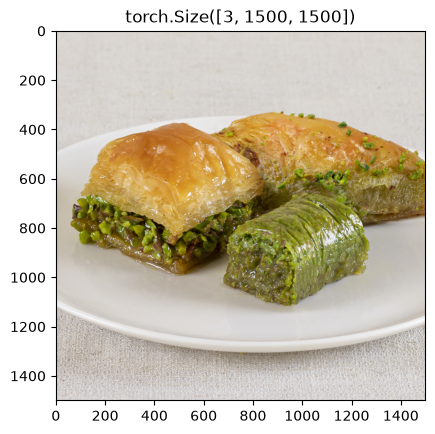

In [87]:
plt.imshow(single_image2.permute(1,2,0))
plt.title(single_image2.shape)

In [88]:
single_image2_transform = transforms.Compose(
    [
        transforms.Resize(size=(128,128)),
        transforms.Normalize(
            mean = [0.485,0.456,0.406],
            std = [0.229,0.224,0.225])
        
    ]
)

single_image2 = single_image2_transform(single_image2)      

In [89]:
single_image2.unsqueeze(dim=0).shape

torch.Size([1, 3, 128, 128])

In [90]:
single_image2.shape

torch.Size([3, 128, 128])

In [91]:
single_image2 = single_image2.unsqueeze(dim=0)

In [92]:
single_image2.shape

torch.Size([1, 3, 128, 128])

In [93]:
single_image2.shape

torch.Size([1, 3, 128, 128])

In [94]:
single_image2 = single_image2.to(device)

In [95]:
model.eval()
with torch.inference_mode():
    logits = model(single_image2)
    probs = torch.softmax(logits,dim=1)
    pred_idx = probs.argmax(dim=1).item()

class_names = train_data.classes 

print(f"Tahmin Edilen Tatlı: {class_names[pred_idx]}")
print(f"Güven Oranı: %{probs[0][pred_idx].item() * 100:.2f}")

Tahmin Edilen Tatlı: baklava
Güven Oranı: %84.09


In [96]:
online_image3_path = data_path / "cupcake.jpg"

In [97]:
single_image3 = torchvision.io.read_image(str(online_image3_path))

In [98]:
single_image3 = torchvision.io.read_image(str(online_image3_path)).type(torch.float32)

In [99]:
single_image3

tensor([[[252., 252., 252.,  ..., 234., 232., 231.],
         [252., 252., 252.,  ..., 234., 232., 231.],
         [252., 252., 252.,  ..., 234., 232., 231.],
         ...,
         [154., 154., 152.,  ..., 123., 124., 126.],
         [149., 148., 147.,  ..., 118., 119., 121.],
         [145., 145., 143.,  ..., 116., 116., 118.]],

        [[240., 240., 238.,  ..., 214., 212., 211.],
         [240., 240., 238.,  ..., 214., 212., 211.],
         [240., 240., 238.,  ..., 214., 212., 211.],
         ...,
         [127., 127., 125.,  ...,   7.,  13.,  17.],
         [122., 121., 120.,  ...,   5.,  10.,  14.],
         [118., 118., 116.,  ...,   3.,   7.,  11.]],

        [[228., 228., 227.,  ..., 203., 201., 200.],
         [228., 228., 227.,  ..., 203., 201., 200.],
         [228., 228., 227.,  ..., 203., 201., 200.],
         ...,
         [110., 110., 108.,  ...,  28.,  32.,  36.],
         [105., 104., 103.,  ...,  25.,  29.,  32.],
         [101., 101.,  99.,  ...,  23.,  26.,  29.]]]

In [100]:
single_image3 = single_image3 / 255

In [101]:
single_image3

tensor([[[0.9882, 0.9882, 0.9882,  ..., 0.9176, 0.9098, 0.9059],
         [0.9882, 0.9882, 0.9882,  ..., 0.9176, 0.9098, 0.9059],
         [0.9882, 0.9882, 0.9882,  ..., 0.9176, 0.9098, 0.9059],
         ...,
         [0.6039, 0.6039, 0.5961,  ..., 0.4824, 0.4863, 0.4941],
         [0.5843, 0.5804, 0.5765,  ..., 0.4627, 0.4667, 0.4745],
         [0.5686, 0.5686, 0.5608,  ..., 0.4549, 0.4549, 0.4627]],

        [[0.9412, 0.9412, 0.9333,  ..., 0.8392, 0.8314, 0.8275],
         [0.9412, 0.9412, 0.9333,  ..., 0.8392, 0.8314, 0.8275],
         [0.9412, 0.9412, 0.9333,  ..., 0.8392, 0.8314, 0.8275],
         ...,
         [0.4980, 0.4980, 0.4902,  ..., 0.0275, 0.0510, 0.0667],
         [0.4784, 0.4745, 0.4706,  ..., 0.0196, 0.0392, 0.0549],
         [0.4627, 0.4627, 0.4549,  ..., 0.0118, 0.0275, 0.0431]],

        [[0.8941, 0.8941, 0.8902,  ..., 0.7961, 0.7882, 0.7843],
         [0.8941, 0.8941, 0.8902,  ..., 0.7961, 0.7882, 0.7843],
         [0.8941, 0.8941, 0.8902,  ..., 0.7961, 0.7882, 0.

Text(0.5, 1.0, 'torch.Size([3, 1500, 1200])')

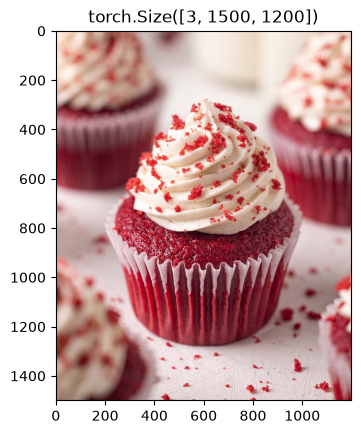

In [102]:
plt.imshow(single_image3.permute(1,2,0))
plt.title(single_image3.shape)

In [103]:
single_image3_transform = transforms.Compose(
    [
        transforms.Resize(size=(128,128)),
        transforms.Normalize(
            mean = [0.485,0.456,0.406],
            std = [0.229,0.224,0.225])
        
    ]
)

single_image3 = single_image3_transform(single_image3)      

In [104]:
single_image3.unsqueeze(dim=0).shape

torch.Size([1, 3, 128, 128])

In [105]:
single_image3 = single_image3.unsqueeze(dim=0)

In [106]:
single_image3 = single_image3.to(device)

In [107]:
model.eval()
with torch.inference_mode():
    logits = model(single_image3)
    probs = torch.softmax(logits,dim=1)
    pred_idx = probs.argmax(dim=1).item()

class_names = train_data.classes 

print(f"Tahmin Edilen Tatlı: {class_names[pred_idx]}")
print(f"Güven Oranı: %{probs[0][pred_idx].item() * 100:.2f}")

Tahmin Edilen Tatlı: cup_cakes
Güven Oranı: %47.07


In [108]:
online_image4_path = data_path / "cannoli.jpg"

In [109]:
single_image4 = torchvision.io.read_image(str(online_image4_path))

In [110]:
single_image4 = torchvision.io.read_image(str(online_image4_path)).type(torch.float32)

In [111]:
single_image4 = single_image4 / 255

Text(0.5, 1.0, 'torch.Size([3, 720, 720])')

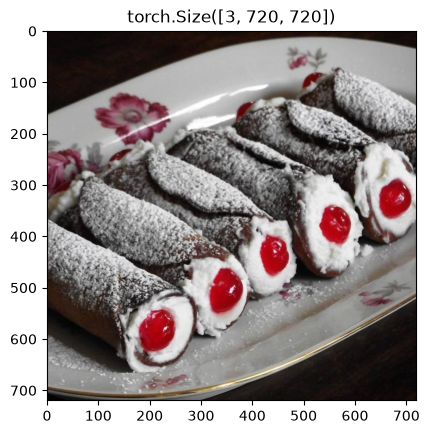

In [112]:
plt.imshow(single_image4.permute(1,2,0))
plt.title(single_image4.shape)

In [113]:
single_image4_transform = transforms.Compose(
    [
        transforms.Resize(size=(128,128)),
        transforms.Normalize(
            mean = [0.485,0.456,0.406],
            std = [0.229,0.224,0.225])
        
    ]
)

single_image4 = single_image4_transform(single_image4)      

In [114]:
single_image4.unsqueeze(dim=0).shape

torch.Size([1, 3, 128, 128])

In [115]:
single_image4 = single_image4.unsqueeze(dim=0)

In [116]:
single_image4 = single_image4.to(device)

In [117]:
model.eval()
with torch.inference_mode():
    logits = model(single_image4)
    probs = torch.softmax(logits,dim=1)
    pred_idx = probs.argmax(dim=1).item()

class_names = train_data.classes 

print(f"Tahmin Edilen Tatlı: {class_names[pred_idx]}")
print(f"Güven Oranı: %{probs[0][pred_idx].item() * 100:.2f}")

Tahmin Edilen Tatlı: cannoli
Güven Oranı: %49.73
